# The bipolar north fold (on tripolar grids): do `diff` and `interp` work across the seam?

Global ocean grids like MOM6, NEMO, and Oceananigans are **tripolar** — the
South Pole plus two poles displaced over Arctic land — and their northern edge
folds onto itself along the **bipolar seam** joining the two northern poles. To
evaluate `interp`/`diff`/`derivative` across that edge, xgcm pads a northern
**halo** by reflecting the interior about the nearest pole (sign-flipping vector
components). If that reconstruction is correct, a physically smooth field stays
**smooth across the seam**.

Rather than map the Arctic (where a polar projection distorts the seam, land
masks it with a blank line, and model noise muddies the picture), we look at the
fold **directly in logical grid-index space** — x-index across, y-index up. The
seam is then just a horizontal line, and the fold's action is plain to see:

* the **halo is the interior reflected about the poles** — so any structure at
  the seam is the model's own field mirrored, *not* a fold artifact;
* the naive `extend` boundary instead **smears the edge value** upward;
* walking a column **across** the seam, the fold **continues** the real field
  while naive **flatlines**.

We show this for **three models** (real surface velocities `u`,`v`): MOM6
(GFDL-CM4) and NEMO (IPSL-CM6A-LR) use a `"corner"` fold pivot, Oceananigans a
`"u"` pivot.

> **Dependencies** — the MOM6/NEMO sections read CMIP6 from the Pangeo cloud
> (`pip install zarr gcsfs`).

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from xgcm import Grid
from xgcm.padding import pad

so = {"storage_options": {"token": "anon"}}
EARTH_RADIUS = 6371e3
OMEGA = 7.2921e-5

## Helpers

`package` puts a model's `u`,`v` on a common staggered index grid and masks land
(cells whose velocity is missing, or zero where zeros dominate — e.g. the
Oceananigans immersed boundary), so land never leaks through `interp`/`diff`.
The diagnostics (`speed_centre`, `speed_corner`, `rossby`) each cross the fold
through a different operation and grid position.

In [2]:
def package(uo, vo, lon, lat, fold, label):
    '''Bundle surface velocities on a common staggered index grid, masking land.'''
    a = lambda x: np.asarray(getattr(x, "values", x), dtype=float)
    uo, vo, lon, lat = a(uo), a(vo), a(lon), a(lat)
    # land = missing, or (where zeros dominate, e.g. immersed boundaries) zero
    def mask_land(z):
        zz = np.where(np.isfinite(z), z, np.nan)
        if np.mean(z == 0) > 0.05:
            zz = np.where(z == 0, np.nan, zz)
        return zz
    uo, vo = mask_land(uo), mask_land(vo)
    ny, nx = uo.shape
    coords = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
    u = xr.DataArray(uo, dims=["y_c", "x_f"]).assign_coords(x_f=coords["x_f"], y_c=coords["y_c"])
    v = xr.DataArray(vo, dims=["y_f", "x_c"]).assign_coords(x_c=coords["x_c"], y_f=coords["y_f"])
    return dict(coords=coords, u=u, v=v, lon=lon, lat=lat, fold=fold, label=label)


def _haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_RADIUS * np.arcsin(np.sqrt(h))


def cell_spacings(lon, lat):
    lonE = np.concatenate([lon, lon[:, :1]], axis=1)
    latE = np.concatenate([lat, lat[:, :1]], axis=1)
    dx = _haversine(lonE[:, :-1], latE[:, :-1], lonE[:, 1:], latE[:, 1:])
    dy = np.empty_like(lat)
    dy[:-1] = _haversine(lon[:-1], lat[:-1], lon[1:], lat[1:])
    dy[-1] = dy[-2]
    return xr.DataArray(dx, dims=["y_f", "x_f"]), xr.DataArray(dy, dims=["y_f", "x_f"])


def _grid(coords, edge, ybc):
    return Grid(xr.Dataset(coords=coords),
                coords={"X": {"center": "x_c", edge: "x_f"},
                        "Y": {"center": "y_c", edge: "y_f"}},
                boundary={"X": "periodic", "Y": ybc}, autoparse_metadata=False)


def speed_centre(m, fold=True):
    '''sqrt(u^2+v^2) at tracer points; the v->centre interp crosses the fold.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if fold else "extend")
    uc = g.interp(m["u"], "X")
    vc = (g.interp({"Y": m["v"]}, "Y", other_component={"X": m["u"]}, boundary="extend")
          if fold else g.interp(m["v"], "Y", boundary="extend"))
    return np.hypot(uc, vc)


def speed_corner(m, fold=True):
    '''sqrt(u^2+v^2) at cell corners; the u->corner interp crosses the fold.'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if fold else "extend")
    vc = g.interp(m["v"], "X")
    uc = (g.interp({"X": m["u"]}, "Y", other_component={"Y": m["v"]}, boundary="extend")
          if fold else g.interp(m["u"], "Y", boundary="extend"))
    return np.hypot(uc, vc)


def rossby(m, fold=True):
    '''Ro = (dv/dx - du/dy)/f at the cell corner; the du/dy diff crosses the fold.'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if fold else "extend")
    dx, dy = cell_spacings(m["lon"], m["lat"])
    dvdx = g.diff(m["v"], "X", boundary="fill") / dx
    dudy = (g.diff({"X": m["u"]}, "Y", other_component={"Y": m["v"]}, boundary="fill")
            if fold else g.diff(m["u"], "Y", boundary="extend")) / dy
    f = xr.DataArray(2 * OMEGA * np.sin(np.radians(m["lat"])), dims=["y_f", "x_f"])
    return (dvdx - dudy) / f

## Seam-space plotting

These draw a zoom of the top rows in logical index space: the interior just
below the seam line, and `K` halo rows above it, reconstructed by `pad(...,
boundary_width={"Y": (0, K)})`. The two dashed verticals mark the pole columns
(the fold's fixed points, at `x = 0` and `x = Nx/2`), about which the halo is
reflected.

In [3]:
def _pad_scalar(S, m, K, mode):
    '''K halo rows above a centre scalar field: fold (mirror) or extend (smear).'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if mode == "fold" else "extend")
    return np.asarray(pad(S, g, boundary_width={"Y": (0, K)}).values)


def _pad_v_vector(m, K, mode):
    '''K halo rows above the v component, folded *as a vector* (sign flips) or
    extended. v lives at (y_f, x_c); pass u as the other (X) component.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if mode == "fold" else "extend")
    out = pad({"Y": m["v"]}, g, boundary_width={"Y": (0, K)}, other_component={"X": m["u"]})
    return np.asarray(out.values)


def _imshow(ax, arr, ny, K, nx, **kw):
    im = ax.imshow(arr, origin="lower", aspect="auto",
                   extent=[-0.5, nx - 0.5, ny - K - 0.5, ny + K - 0.5], **kw)
    ax.axhline(ny - 0.5, color="k", lw=1.6)                       # the fold seam
    for px in (0, nx // 2):
        ax.axvline(px, color="0.45", ls="--", lw=1.0)            # pole columns
    ax.set_xticks([0, nx // 2, nx - 1])
    return im


def seam_strip(models, K=6):
    '''Centre surface-speed near the seam: naive halo / fold halo / difference.
    Interior (below the line) is identical; the fold halo mirrors the interior
    about the poles while naive smears the edge upward.'''
    rlab = ["naive halo\n(extend)", "fold halo\n(mirror)", "naive − fold"]
    fig, axes = plt.subplots(3, len(models), figsize=(5.2 * len(models), 9.2))
    for c, m in enumerate(models):
        S = speed_centre(m, True)
        ny, nx = S.sizes["y_c"], S.sizes["x_c"]
        Sf = _pad_scalar(S, m, K, "fold")[ny - K:ny + K]
        Se = _pad_scalar(S, m, K, "extend")[ny - K:ny + K]
        seam = S.values[ny - K:ny]
        vmax = np.nanpercentile(seam[np.isfinite(seam)], 95) if np.isfinite(seam).any() else 1.0
        vmax = vmax or 1.0
        dd = (Se - Sf) / vmax                                     # difference in units of vmax
        seq = plt.get_cmap("viridis").copy(); seq.set_bad("white")
        div = plt.get_cmap("RdBu_r").copy(); div.set_bad("white")
        for r, arr, cmap, kw in [
            (0, Se / vmax, seq, dict(vmin=0, vmax=1)),
            (1, Sf / vmax, seq, dict(vmin=0, vmax=1)),
            (2, dd, div, dict(vmin=-1, vmax=1)),
        ]:
            _imshow(axes[r, c], arr, ny, K, nx, cmap=cmap, **kw)
            if r == 0:
                axes[r, c].set_title(m["label"], fontsize=10)
            if c == 0:
                axes[r, c].set_ylabel(rlab[r], fontsize=9)
            if r == 2:
                axes[r, c].set_xlabel("X index")
    for r, lab in [(0, "speed / max"), (1, "speed / max"), (2, "(naive−fold) / max")]:
        fig.colorbar(axes[r, -1].images[0],
                     ax=list(axes[r, :]), shrink=0.7, pad=0.02, label=lab)
    fig.suptitle("Surface speed near the seam (per-model scale): the fold halo mirrors the interior;\n"
                 "naive 'extend' smears the edge. Interior below the line is untouched (difference ≈ 0).",
                 fontsize=12, y=0.97)
    plt.show()


def component_strip(models, K=6):
    '''The v velocity component near the seam, folded as a vector. The halo is
    the interior reflected about the poles AND sign-flipped (180° pivot): across
    the seam near a pole the colour inverts. A scalar would not flip.'''
    fig, axes = plt.subplots(1, len(models), figsize=(5.2 * len(models), 3.6))
    axes = np.atleast_1d(axes)
    for c, (ax, m) in enumerate(zip(axes, models)):
        ny, nx = m["coords"]["y_c"].size, m["coords"]["x_c"].size
        Vf = _pad_v_vector(m, K, "fold")[ny - K:ny + K]
        vmax = np.nanpercentile(np.abs(Vf[np.isfinite(Vf)]), 95) if np.isfinite(Vf).any() else 1.0
        vmax = vmax or 1.0
        div = plt.get_cmap("RdBu_r").copy(); div.set_bad("white")
        im = _imshow(ax, Vf / vmax, ny, K, nx, cmap=div, vmin=-1, vmax=1)
        ax.set_title(m["label"], fontsize=10)
        ax.set_xlabel("X index")
        if c == 0:
            ax.set_ylabel("v (folded as vector)\n/ max", fontsize=9)
    fig.colorbar(im, ax=list(axes), shrink=0.8, pad=0.02, label="v / max")
    fig.suptitle("Meridional velocity v near the seam (fold halo): the interior reflected "
                 "AND sign-flipped\n(colour inverts across the seam) — the signature of correct "
                 "vector folding", fontsize=12, y=1.02)
    plt.show()


def seam_transect(models, K=6, ncols=4):
    '''Continue surface speed (a scalar) across the seam into the halo. The fold
    fills the halo with the true seam-partner row, continuing the field; the
    naive boundary just repeats the edge value (a flat line). A few ocean
    columns per model.'''
    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.2))
    axes = np.atleast_1d(axes)
    for k, (ax, m) in enumerate(zip(axes, models)):
        S = speed_centre(m, True)
        ny = S.sizes["y_c"]
        Sf = _pad_scalar(S, m, K, "fold")
        Se = _pad_scalar(S, m, K, "extend")
        x = np.arange(ny - K, ny + K)
        approach = np.isfinite(Sf[ny - K:ny]).all(axis=0)
        nfin = np.isfinite(Sf[ny - K:ny + K]).sum(axis=0)
        good = np.where(approach & (nfin >= K + 2))[0]
        if good.size == 0:                       # coarse, land-locked cap: most-finite cols
            good = np.argsort(nfin)[::-1][:ncols]
        sel = good[np.linspace(0, len(good) - 1, min(ncols, len(good))).astype(int)]
        for j, i in enumerate(sel):
            lab = (j == 0 and k == 0)
            ax.plot(x, Se[ny - K:ny + K, i], "o--", color="C1", ms=3, alpha=.8,
                    label="naive (extend)" if lab else None)
            ax.plot(x, Sf[ny - K:ny + K, i], "o-", color="C0", ms=3, alpha=.9,
                    label="fold" if lab else None)
        ax.axvline(ny - 0.5, color="k", ls=":", alpha=.6, label="seam" if k == 0 else None)
        ax.set_title(m["label"], fontsize=10)
        ax.set_xlabel("Y index  (interior → halo)")
        if k == 0:
            ax.set_ylabel("surface speed [m s$^{-1}$]")
    axes[0].legend(fontsize=8, loc="best")
    fig.suptitle("Across the seam the fold continues the real field; the naive boundary flatlines",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


def rossby_seam(models, K=4):
    '''The `diff`-based diagnostic. Ro = ζ/f at the corner, naive vs fold, near
    the seam in index space (difference normalised per model). The fold corrects
    ζ exactly along the seam row; elsewhere naive and fold agree.'''
    fig, axes = plt.subplots(1, len(models), figsize=(5.2 * len(models), 3.4))
    axes = np.atleast_1d(axes)
    for c, (ax, m) in enumerate(zip(axes, models)):
        ny, nx = m["coords"]["y_c"].size, m["coords"]["x_c"].size
        d = np.asarray((rossby(m, False) - rossby(m, True)).values)[ny - K:ny]
        vmax = np.nanpercentile(np.abs(d[np.isfinite(d)]), 98) if np.isfinite(d).any() else 1.0
        vmax = vmax or 1.0
        div = plt.get_cmap("RdBu_r").copy(); div.set_bad("white")
        im = ax.imshow(d / vmax, origin="lower", aspect="auto",
                       extent=[-0.5, nx - 0.5, ny - K - 0.5, ny - 0.5], cmap=div, vmin=-1, vmax=1)
        ax.axhline(ny - 1.5, color="k", lw=1.0, ls=":")          # last (seam) row boundary
        for px in (0, nx // 2):
            ax.axvline(px, color="0.45", ls="--", lw=1.0)
        ax.set_xticks([0, nx // 2, nx - 1]); ax.set_title(m["label"], fontsize=10)
        ax.set_xlabel("X index")
        if c == 0:
            ax.set_ylabel("Y index", fontsize=9)
    fig.colorbar(im, ax=list(axes), shrink=0.8, pad=0.02, label="(naive−fold) Ro / max")
    fig.suptitle("Rossby number ζ/f from `diff`: naive − fold is confined to the seam row "
                 "(the fold corrects ∂u/∂y there)", fontsize=12, y=1.02)
    plt.show()

## Load the three models

CMIP6 surface velocities for MOM6 (GFDL-CM4) and NEMO (IPSL-CM6A-LR) from the
Pangeo cloud, plus a realistic 1° ClimaOcean/Oceananigans surface snapshot.
CMIP6 masks its redundant northern row, so we drop it before folding.

In [4]:
def _cmip6_surface(source_id, version, fold, label):
    inst = {"GFDL-CM4": "NOAA-GFDL", "IPSL-CM6A-LR": "IPSL"}[source_id]
    base = (f"gs://cmip6/CMIP6/CMIP/{inst}/{source_id}/historical/"
            f"r1i1p1f1/Omon/{{var}}/gn/{version}/")

    def s(var):
        d = xr.open_dataset(base.format(var=var), engine="zarr", backend_kwargs=so)
        return d[var].isel(time=0).isel({d[var].dims[1]: 0})

    uo = s("uo").isel(y=slice(0, -1))
    vo = s("vo").isel(y=slice(0, -1))
    g = xr.open_dataset(base.format(var="uo"), engine="zarr", backend_kwargs=so)
    lonn = "lon" if "lon" in g.variables else "nav_lon"
    latn = "lat" if "lat" in g.variables else "nav_lat"
    return package(uo, vo, g[lonn].isel(y=slice(0, -1)).values,
                   g[latn].isel(y=slice(0, -1)).values, fold, label)


def _oceananigans():
    o = xr.open_dataset("oceananigans_tripolar.nc")
    return package(o["u"].transpose("y_c", "x_f"), o["v"].transpose("y_f", "x_c"),
                   o["lon_cc"].transpose("y_c", "x_c"), o["lat_cc"].transpose("y_c", "x_c"),
                   "u", "Oceananigans (ClimaOcean 1°)")


models = [
    _cmip6_surface("GFDL-CM4", "v20180701", "corner", "MOM6 (GFDL-CM4)"),
    _cmip6_surface("IPSL-CM6A-LR", "v20180803", "corner", "NEMO (IPSL-CM6A-LR)"),
    _oceananigans(),
]

## `interp` across the fold — the halo is the interior, reflected

Surface speed at tracer (centre) points near the seam. The **interior** (below
the black line) is the real field. The **fold halo** above the line is that
interior *reflected about the poles* — the same structures, mirrored — so it
continues the field across the seam. The **naive** `extend` halo instead copies
the edge value straight up (vertical streaks). The **difference** is zero in the
interior and nonzero only in the halo: the fold changes nothing inside, it only
supplies a physically correct neighbourhood beyond the edge.

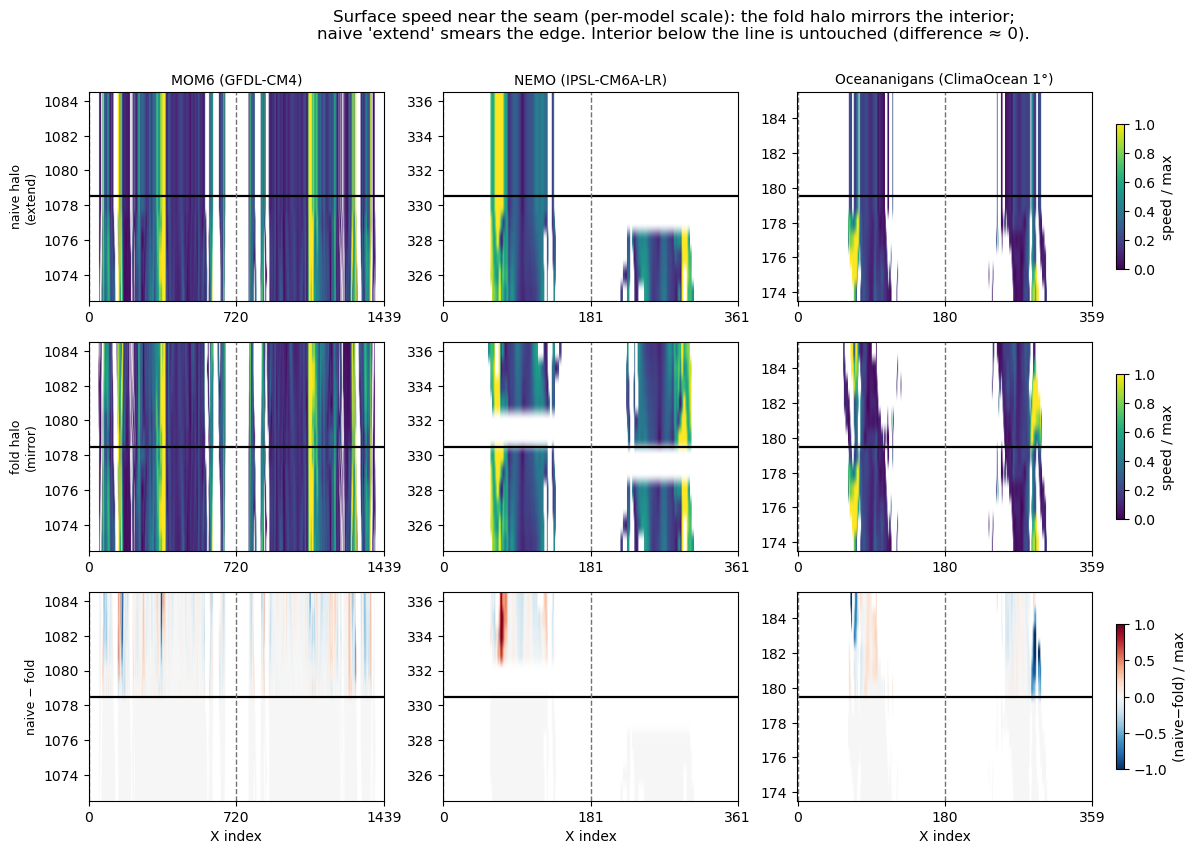

In [5]:
seam_strip(models)

## Vector components flip sign across the seam

The same reflection, but for the meridional velocity `v` folded **as a vector**
(passing the other component via `other_component`). Folding the grid rotates the
local axes by 180°, so the halo is the reflected interior **with the sign
reversed** — across the seam near a pole the colour inverts. A scalar (above)
does not flip; a velocity does.

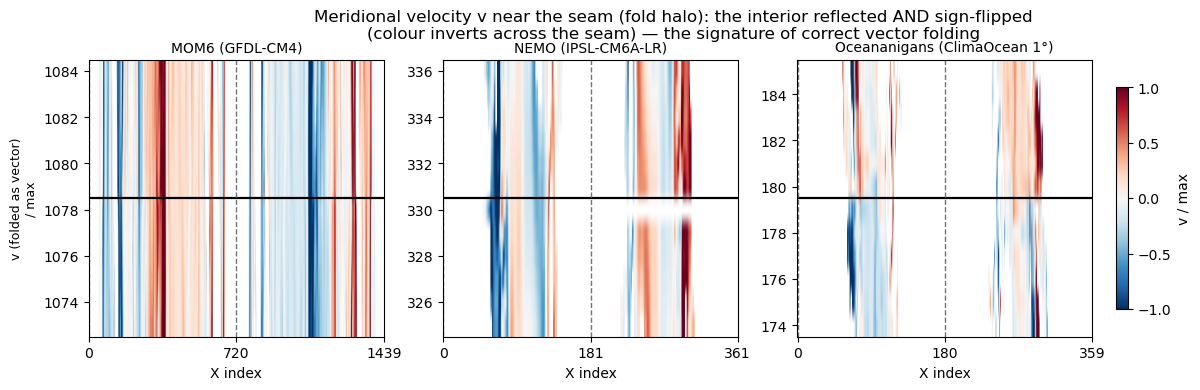

In [6]:
component_strip(models)

## Continuity across the seam — a transect

The cleanest correctness check: follow a few ocean columns from the interior,
across the seam (dotted), into the halo. The **fold** continues the real,
varying field (the seam partner is a genuine physical neighbour); the **naive**
boundary flatlines at the edge value. Where a column's halo runs into Arctic
land the line simply stops — there is no data there, but that is land, not a
fold error.

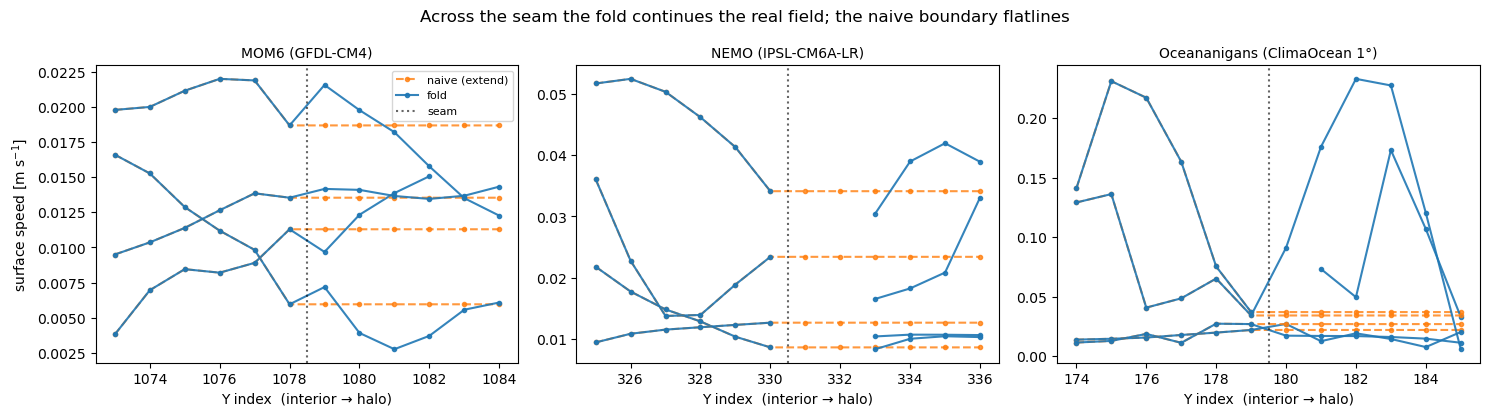

In [7]:
seam_transect(models)

## `diff` across the fold — Rossby number $\zeta/f$

The same holds for differencing: $\zeta=\partial v/\partial x-\partial u/\partial y$
at the cell corner, where $\partial u/\partial y$ crosses the seam. Comparing the
naive and fold results, they agree everywhere except the seam row, where the fold
supplies the correct cross-seam neighbour for the derivative.

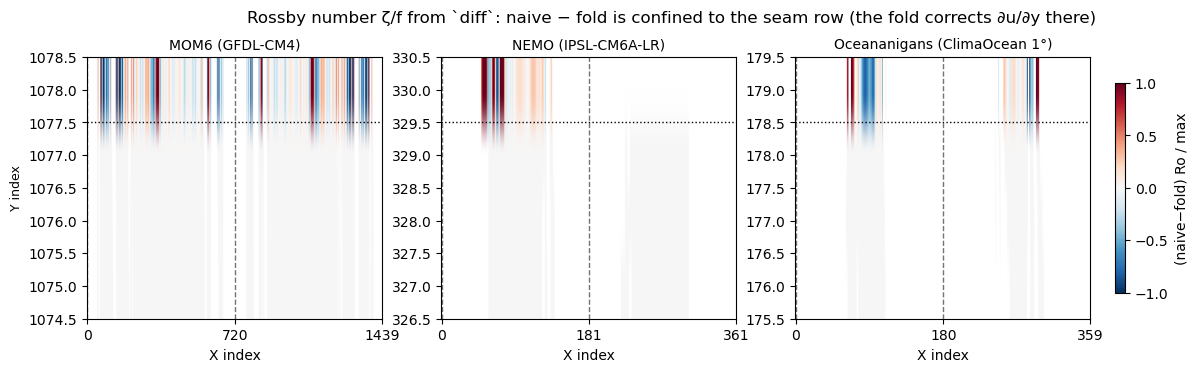

In [8]:
rossby_seam(models)

## Takeaway

Seen directly in grid-index space, the bipolar north fold is transparent: xgcm
fills the northern halo with the interior **reflected about the poles**,
sign-flipping vector components. So

* a smooth scalar (surface speed) **continues across the seam** — the fold halo
  is the mirrored interior, the transect stays continuous — while the naive
  `extend` boundary smears the edge and flatlines;
* a velocity component additionally **reverses sign** across the seam, the
  signature of the 180° pivot;
* `diff`-based diagnostics (the Rossby number) are corrected **exactly along the
  seam row** and left untouched elsewhere.

Because the halo is provably the reflected interior, any wiggle at the seam — for
instance the grid-scale noise in the coarse, short-spin-up Oceananigans field —
is the **model's own velocity field, faithfully mirrored**, not an artifact of
the fold operators. The mirror symmetry is the tell. xgcm's
`boundary={"X": "periodic", "Y": {"fold": ...}}` makes the standard staggered
`interp`/`diff`/`derivative` work across the pole for all three models'
conventions (`"corner"` for MOM6/NEMO, `"u"` for Oceananigans).

See the [grid topology](../grid_topology.md) docs for the four fold pivots and
how the halo is filled, and [`03_MOM6.ipynb`](03_MOM6.ipynb) for more MOM6
recipes.